In [1]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# --- Configurations ---
DATA_PATH = r'D:\BE. CSE\Sem 6\IoT_lab\sr\baby_cry_detector\dataset' # Update if needed
CATEGORIES = ['baby_cry', 'baby_laugh', 'noise', 'silence']

SR = 22050        # Sample rate
DURATION = 5      # 5 seconds
MAX_LEN = SR * DURATION

In [3]:
def extract_robust_features(file_path, n_mels=40):
    try:
        # 1. Load the audio
        y, sr = librosa.load(file_path, sr=SR, duration=DURATION)
        
        # 2. Pad or truncate to exactly 5 seconds
        if len(y) < MAX_LEN:
            y = np.pad(y, (0, MAX_LEN - len(y)))
        else:
            y = y[:MAX_LEN]
            
        # 3. Smart Volume Normalization (The Fix)
        # Only normalize if the sound is actually audible (max amplitude > 0.01)
        # Otherwise, leave it alone so 'silence' stays 'silence'
        max_amp = np.max(np.abs(y))
        if max_amp > 0.01:
            y = y / max_amp
            
        # 4. Generate Mel Spectrogram
        melspec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, n_fft=2048, hop_length=512
        )
        
        # 5. Convert to Decibels
        log_melspec = librosa.power_to_db(melspec, ref=np.max)
        
        # 6. Min-Max Scale to [0, 1]
        log_melspec = (log_melspec - np.min(log_melspec)) / (np.max(log_melspec) - np.min(log_melspec) + 1e-10)
        
        return log_melspec.astype(np.float32)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [ ]:
print("Extracting features from dataset... This might take a few minutes.")

X, y_labels = [], []

for label in CATEGORIES:
    folder_path = os.path.join(DATA_PATH, label)
    if not os.path.exists(folder_path):
        print(f"Warning: Folder not found {folder_path}")
        continue
        
    for filename in os.listdir(folder_path):
        if filename.endswith('.wav') or filename.endswith('.m4a'):
            file_path = os.path.join(folder_path, filename)
            features = extract_robust_features(file_path)
            
            if features is not None:
                # Add the feature to our dataset
                X.append(features)
                y_labels.append(label)
                
                # --- THE FIX: OVERSAMPLING ---
                # If it's a baby cry, add it 2 more times to balance the 40 up to 120!
                if label == 'baby_cry':
                    X.append(features)
                    y_labels.append(label)
                    X.append(features)
                    y_labels.append(label)

X = np.array(X)
X = X[..., np.newaxis] 
y_labels = np.array(y_labels)

print(f"Successfully loaded {len(X)} audio samples.")
print("New Data distribution:")
unique, counts = np.unique(y_labels, return_counts=True)
for l, c in zip(unique, counts):
    print(f"{l}: {c} samples")

Extracting features from dataset... This might take a few minutes.


C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Successfully loaded 364 audio samples.
Feature shape: (364, 40, 216, 1)


In [5]:
# Force LabelEncoder to use our exact category order
le = LabelEncoder()
le.fit(CATEGORIES) 
y_encoded = le.transform(y_labels)
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=len(CATEGORIES))

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 291
Testing samples: 73


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# 1. Calculate how much weight to give each class based on the data
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_encoded), 
    y=y_encoded
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class Weights applied: {class_weight_dict}")

# 2. Train the model with the new penalties
history = model.fit(
    X_train, y_train, 
    epochs=25, 
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict  # <--- THE FIX
)

# Plot accuracy to see how well it learned
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Final Test Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 38, 214, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 19, 107, 32)      0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 19, 107, 32)      128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 17, 105, 64)       18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 52, 64)        0         
 2D)                                                             
                                                        

Epoch 1/25
10/10 [==============================] - 4s 257ms/step - loss: 1.7295 - accuracy: 0.6048 - val_loss: 1.2883 - val_accuracy: 0.3973
Epoch 2/25
10/10 [==============================] - 2s 183ms/step - loss: 1.1032 - accuracy: 0.8144 - val_loss: 1.4333 - val_accuracy: 0.2466
Epoch 3/25
10/10 [==============================] - 2s 196ms/step - loss: 0.5577 - accuracy: 0.8660 - val_loss: 1.5321 - val_accuracy: 0.3014
Epoch 4/25
10/10 [==============================] - 3s 317ms/step - loss: 0.7222 - accuracy: 0.8763 - val_loss: 1.9820 - val_accuracy: 0.2877
Epoch 5/25
10/10 [==============================] - 3s 283ms/step - loss: 0.2891 - accuracy: 0.9210 - val_loss: 4.3319 - val_accuracy: 0.3014
Epoch 6/25
10/10 [==============================] - 3s 288ms/step - loss: 0.2046 - accuracy: 0.9519 - val_loss: 5.0505 - val_accuracy: 0.3014
Epoch 7/25
10/10 [==============================] - 3s 250ms/step - loss: 0.3332 - accuracy: 0.9107 - val_loss: 5.6328 - val_accuracy: 0.3014
Epoch 

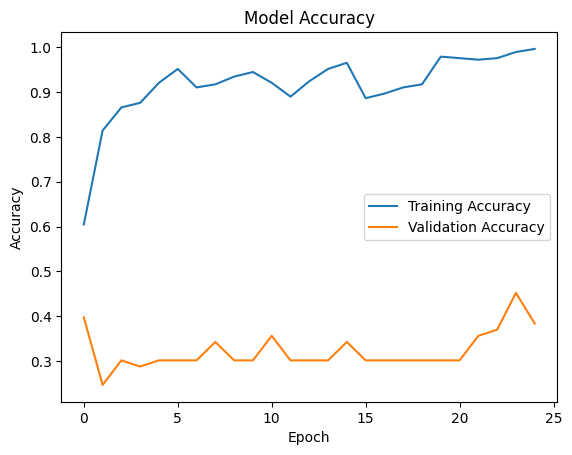

3/3 [==============================] - 0s 48ms/step - loss: 12.4902 - accuracy: 0.3836
Final Test Accuracy: 38.36%


In [7]:
history = model.fit(
    X_train, y_train, 
    epochs=25, 
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Plot accuracy to see how well it learned
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Final Test Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

In [8]:
# Convert directly to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the file
tflite_filename = "baby_sound_classifier_v2.tflite"
with open(tflite_filename, "wb") as f:
    f.write(tflite_model)

print(f"Model successfully saved as {tflite_filename}!")

INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpwh3_tq37\assets


INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpwh3_tq37\assets


Model successfully saved as baby_sound_classifier_v2.tflite!


In [9]:
# Check if the dataset is balanced
unique, counts = np.unique(y_labels, return_counts=True)
print("Data distribution:")
for label, count in zip(unique, counts):
    print(f"{label}: {count} samples")

Data distribution:
baby_cry: 40 samples
baby_laugh: 108 samples
noise: 108 samples
silence: 108 samples
